In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
import joblib
from scipy.ndimage import uniform_filter1d

In [2]:
model = joblib.load("hog_manual_svm_model.joblib")

f:\Apps\Anaconda\envs\IP2\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
label_encoder = joblib.load("label_encoder.joblib")

f:\Apps\Anaconda\envs\IP2\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [250]:
img = cv2.imread("ocr.jpeg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

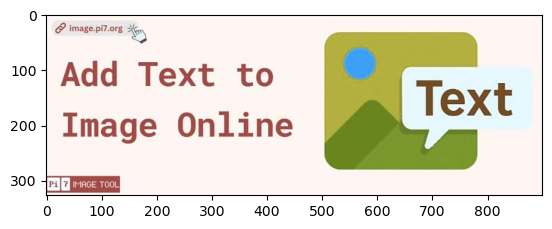

In [251]:
plt.imshow(img)

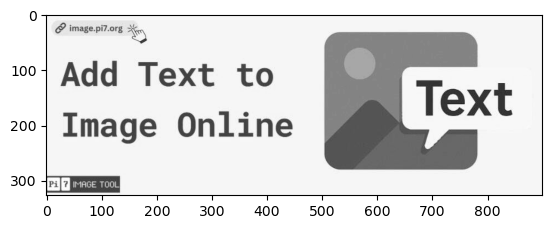

In [252]:
plt.imshow(gray, cmap='gray')

In [253]:
mser = cv2.MSER_create()
mser.setMinArea(200)

In [254]:
def merge_boxes(boxes, threshold=0.3):
    merged = []

    for box in boxes:
        x, y, w, h = box
        if w == 0 or h == 0:
            continue

        added = False

        for i, (mx, my, mw, mh) in enumerate(merged):

            # compute IoU
            xi1 = max(x, mx)
            yi1 = max(y, my)
            xi2 = min(x + w, mx + mw)
            yi2 = min(y + h, my + mh)

            inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)

            area1 = w * h
            area2 = mw * mh
            union = area1 + area2 - inter

            iou = inter / (union + 1e-6)

            if iou > threshold:
                # merge boxes
                nx = min(x, mx)
                ny = min(y, my)
                nw = max(x + w, mx + mw) - nx
                nh = max(y + h, my + mh) - ny

                merged[i] = (nx, ny, nw, nh)
                added = True
                break

        if not added:
            merged.append((x, y, w, h))

    return merged

In [255]:
# def remove_holes(boxes, threshold=0.5):
#     filtered = []
#     for box in boxes:
#         x, y, w, h = box
#         roi = gray[y:y+h, x:x+w]
#         roi = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
#         total_pixels = w * h
#         white_pixels = cv2.countNonZero(roi)
#         if white_pixels / total_pixels > threshold:
#             filtered.append(box)
#     return filtered

Number of regions: 667
Number of boxes: 667
Number of unique boxes: 39


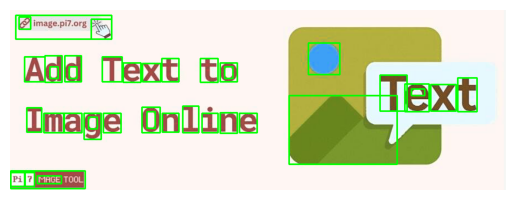

In [256]:
plt.axis('off')

regions, boxes = mser.detectRegions(gray)
unique_boxes = set(tuple(b) for b in boxes)
unique_boxes = [list(b) for b in unique_boxes]
unique_boxes = merge_boxes(unique_boxes, threshold=0.3)

print(f"Number of regions: {len(regions)}")
print(f"Number of boxes: {len(boxes)}")
print(f"Number of unique boxes: {len(unique_boxes)}")

img_copy = img.copy()
for i in range(len(unique_boxes)):
    x, y, w, h = unique_boxes[i]
    cv2.rectangle(img_copy, (x, y), (x + w, y + h), (0, 255, 0), 2)
plt.imshow(img_copy)
plt.show()


In [257]:
def merge_char_words(boxes, x_thresh=20, y_thresh=10):
    used = [False] * len(boxes)
    words = []

    for i in range(len(boxes)):
        if used[i]:
            continue

        word = [boxes[i]]
        used[i] = True

        changed = True

        while changed:
            changed = False

            for j in range(len(boxes)):
                if used[j]:
                    continue

                x1, y1, w1, h1 = boxes[j]

                for wx, wy, ww, wh in word:
                    # check same line
                    if abs(wy - y1) < y_thresh:
                        # check horizontal gap
                        if abs((wx + ww) - x1) < x_thresh or abs((x1 + w1) - wx) < x_thresh:
                            word.append(boxes[j])
                            used[j] = True
                            changed = True
                            break

        words.append(sorted(word, key=lambda b: b[0]))

    return words

In [258]:
def get_word_boxes(words):
    word_boxes = []

    for word in words:
        x_min = min(x for x, y, w, h in word)
        y_min = min(y for x, y, w, h in word)
        x_max = max(x + w for x, y, w, h in word)
        y_max = max(y + h for x, y, w, h in word)

        word_boxes.append((x_min, y_min, x_max - x_min, y_max - y_min))

    return word_boxes

In [259]:
words = merge_char_words(unique_boxes, x_thresh=20, y_thresh=30)
print(f"Number of words: {len(words)}")

Number of words: 12


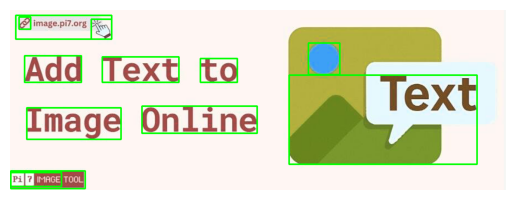

12


In [260]:
word_boxes = get_word_boxes(words)

img_copy = img.copy()

for (x, y, w, h) in word_boxes:
    cv2.rectangle(
        img_copy,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

plt.imshow(img_copy)
plt.axis("off")
plt.show()
print(len(words))

In [261]:
IMG_SIZE = 128
def calc_gradients(image):
    Gx = np.array([[-1, 0, 1]], dtype=np.float32)
    Gy = np.array([[-1], [0], [1]], dtype=np.float32)

    image = image.astype(np.float32)

    gx = cv2.filter2D(image, -1, Gx)
    gy = cv2.filter2D(image, -1, Gy)
    
    gradients_magnitude = np.sqrt(gx**2 + gy**2)
    gradients_orientation = (np.arctan2(gy, gx) * 180 / np.pi) % 180

    return gradients_magnitude, gradients_orientation


def HoG(orientations, magnitudes, cell_size=16, num_bins=9, block_size=2):
    bin_size = 180 / num_bins

    h, w = orientations.shape
    cells_y = h // cell_size
    cells_x = w // cell_size

    histograms = np.zeros((cells_y, cells_x, num_bins), dtype=np.float32)
    
    for cy in range(cells_y):
        for cx in range(cells_x):
            y0 = cy * cell_size
            x0 = cx * cell_size

            for y in range(cell_size):
                for x in range(cell_size):
                    angle = orientations[y0 + y, x0 + x]
                    mag = magnitudes[y0 + y, x0 + x]

                    bin_idx = int(angle / bin_size) % num_bins
                    histograms[cy, cx, bin_idx] += mag
                    
    features = []

    for y in range(cells_y - 1):
        for x in range(cells_x - 1):
            block = histograms[y:y+block_size, x:x+block_size].flatten()

            norm = np.linalg.norm(block)
            block = block / (norm + 1e-6)

            features.extend(block)

    return np.array(features, dtype=np.float32)

In [262]:

def predict(image, model=model, le=label_encoder):
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    # image = image.astype(np.float32) / 255.0
    magnitudes, orientations = calc_gradients(image)
    # test_features = HoG(orientations, magnitudes, cell_size=16, num_bins=9, block_size=2).reshape(1, -1)
    magnitudes, orientations = calc_gradients(image)
    test_features = HoG(orientations, magnitudes, cell_size=16, num_bins=9, block_size=2).reshape(1, -1)
    predicted_label = model.predict(test_features)
    scores = model.decision_function(test_features)
    return predicted_label, scores

In [263]:
def sort_boxes_reading_order(boxes, y_thresh=10):
    # first sort by y
    boxes = sorted(boxes, key=lambda b: b[1])

    lines = []

    for box in boxes:
        x, y, w, h = box
        placed = False

        for line in lines:
            if abs(line[0][1] - y) < y_thresh:
                line.append(box)
                placed = True
                break

        if not placed:
            lines.append([box])

    # sort each line by x
    for line in lines:
        line.sort(key=lambda b: b[0])

    # flatten
    return [b for line in lines for b in line]

Number of words: 12
Predicted label for test image: M


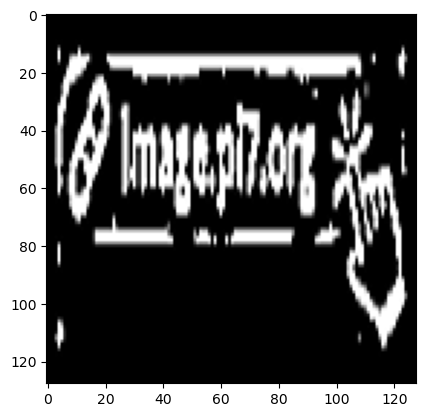

Predicted label for test image: R


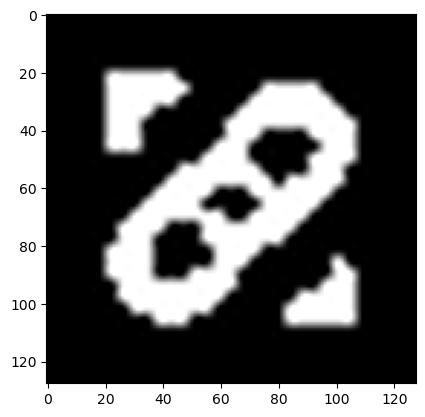

Predicted label for test image: S


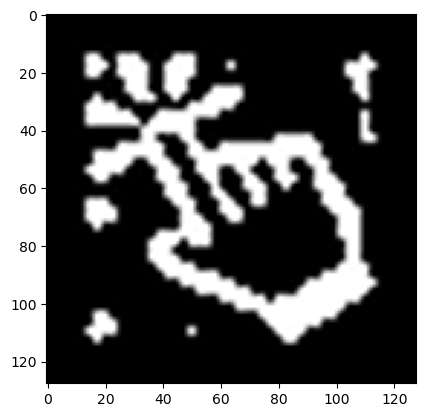

Predicted label for test image: U


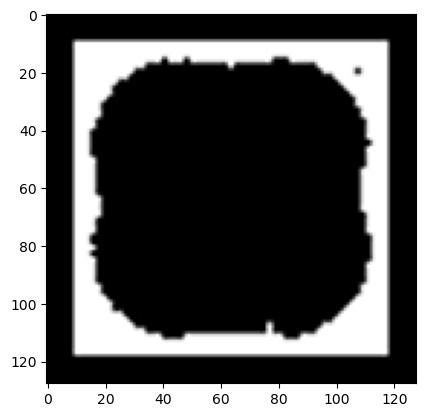

Predicted label for test image: E


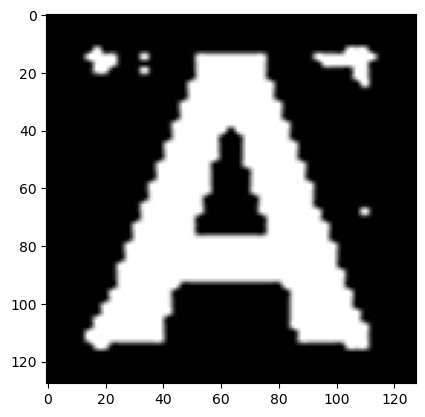

Predicted label for test image: d


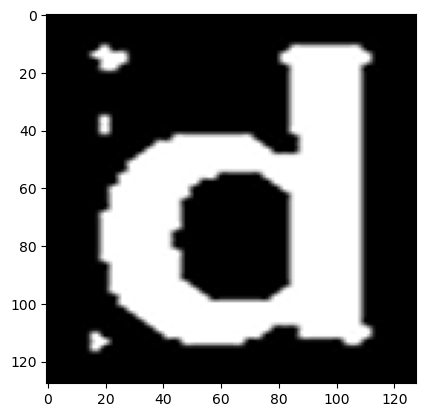

Predicted label for test image: U


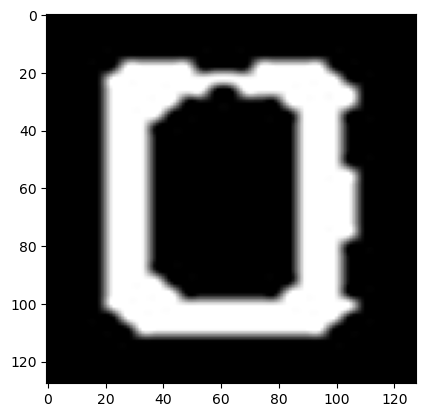

Predicted label for test image: H


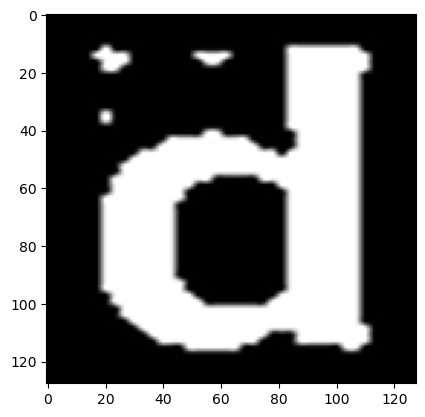

Predicted label for test image: U


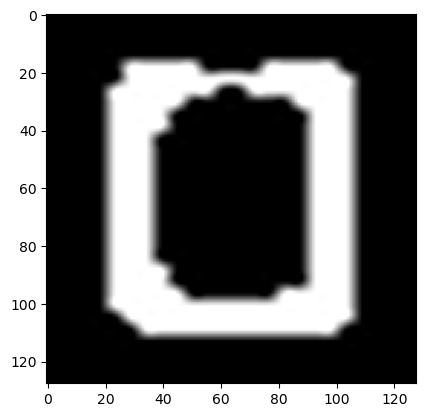

Predicted label for test image: a


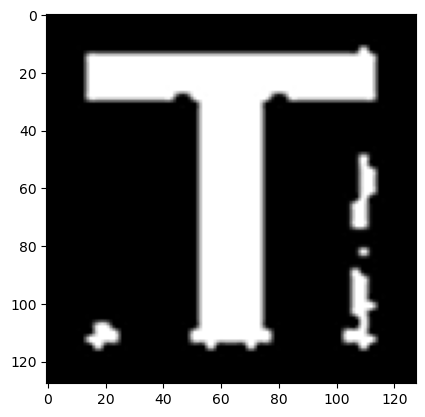

Predicted label for test image: e


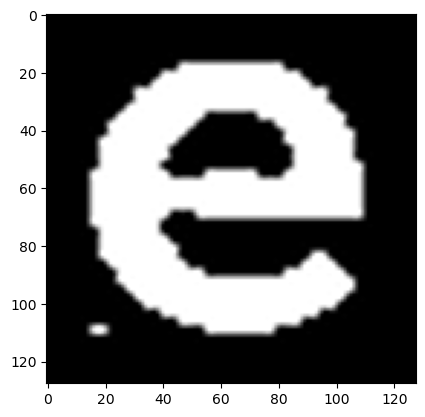

Predicted label for test image: X


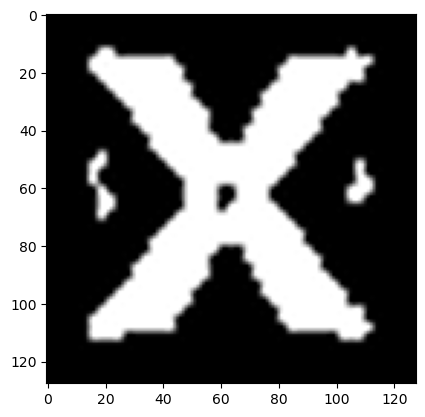

Predicted label for test image: t


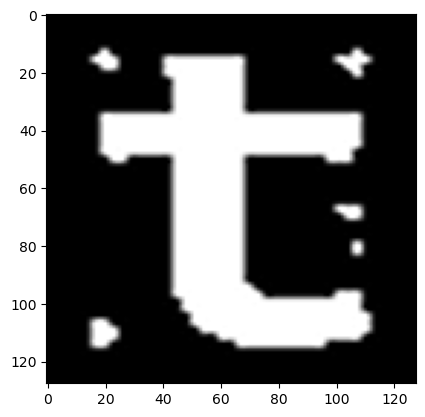

Predicted label for test image: H


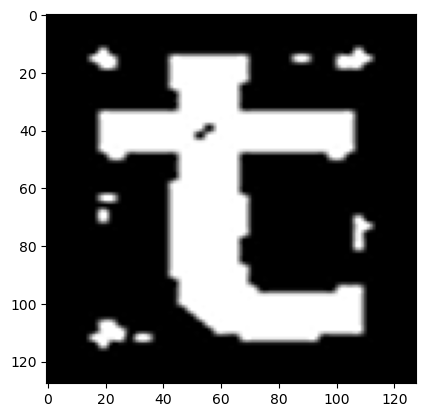

Predicted label for test image: a


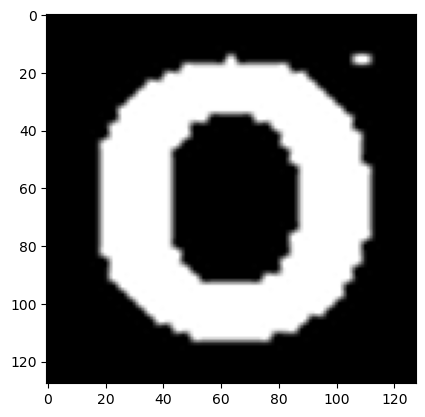

Predicted label for test image: O


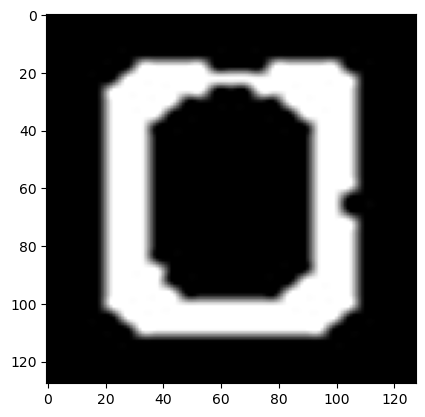

Predicted label for test image: g


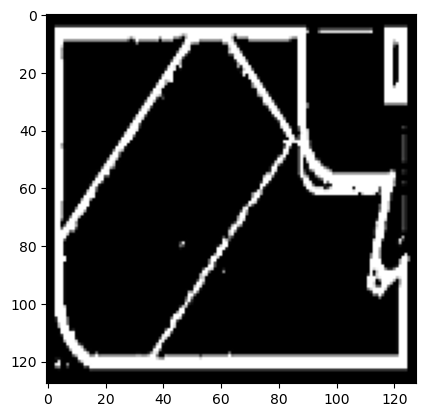

Predicted label for test image: M


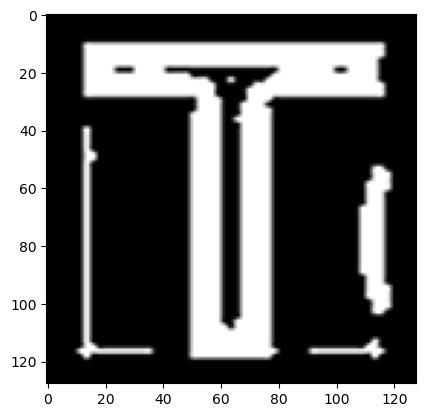

Predicted label for test image: e


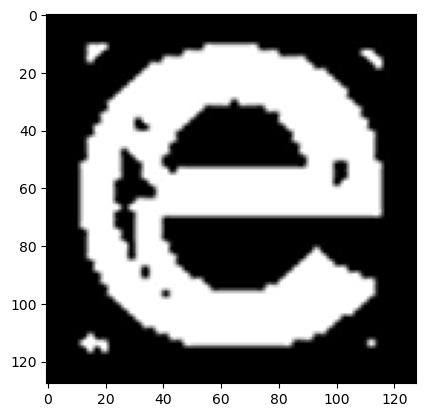

Predicted label for test image: 5


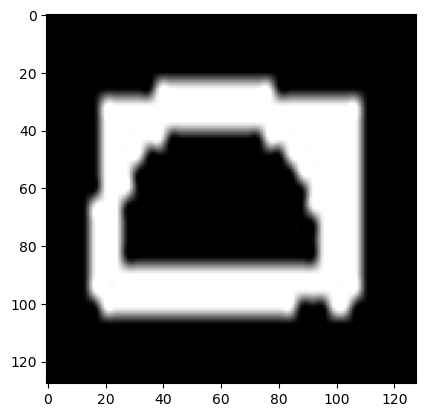

Predicted label for test image: X


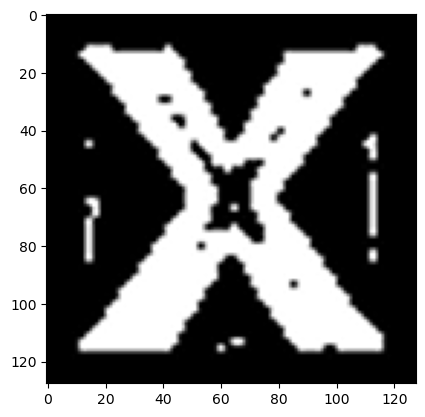

Predicted label for test image: H


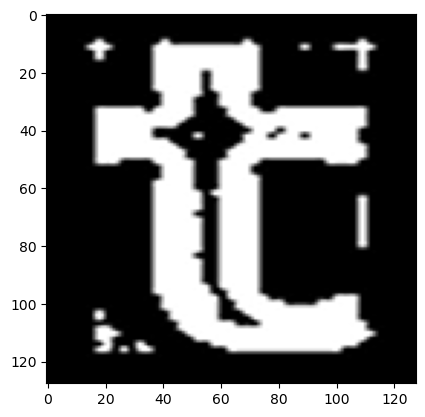

Predicted label for test image: H


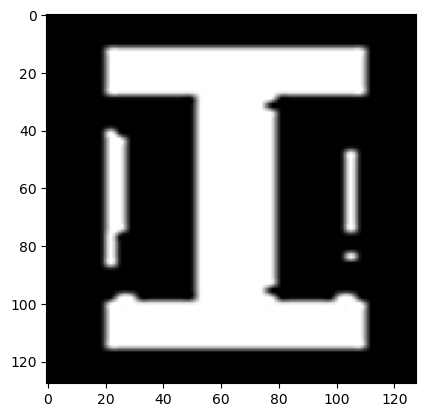

Predicted label for test image: M


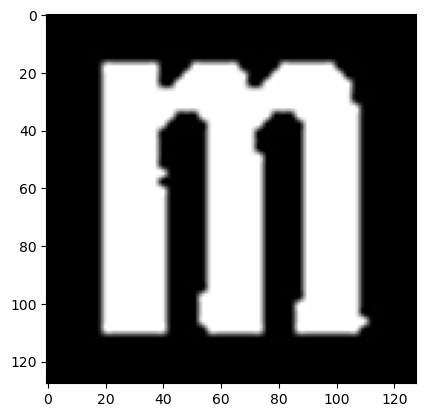

Predicted label for test image: a


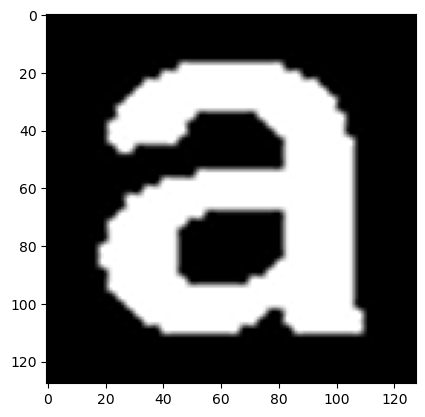

Predicted label for test image: g


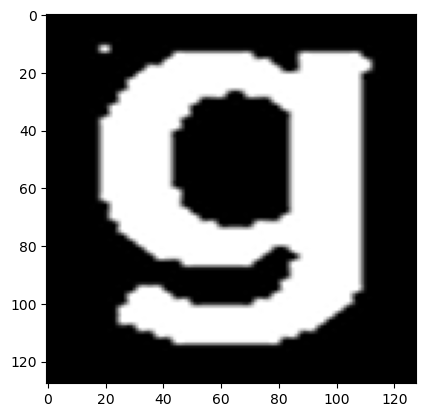

Predicted label for test image: U


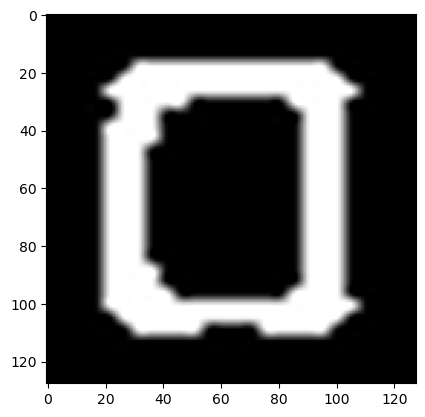

Predicted label for test image: e


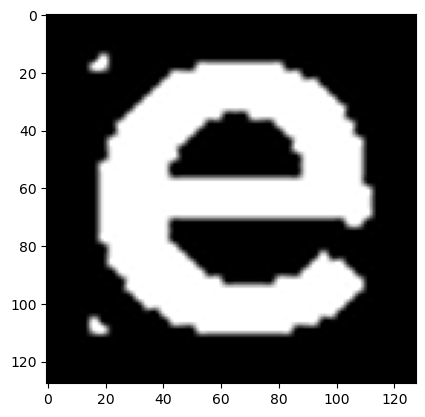

Predicted label for test image: a


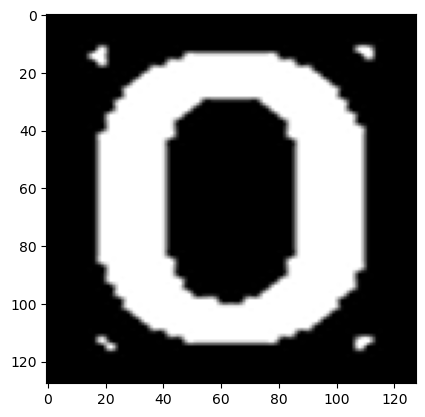

Predicted label for test image: n


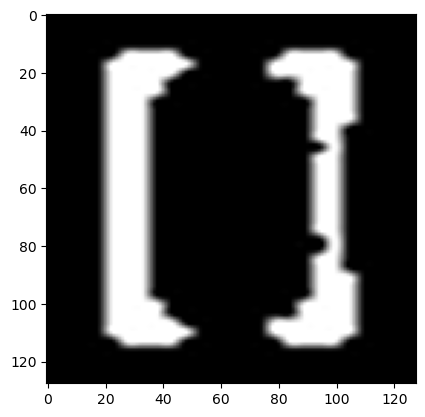

Predicted label for test image: n


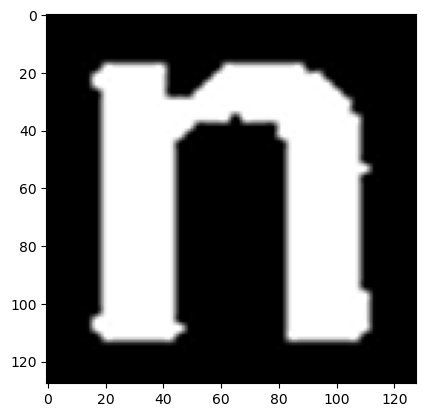

Predicted label for test image: n


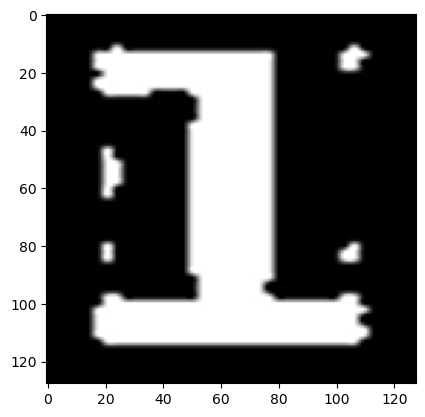

Predicted label for test image: 1


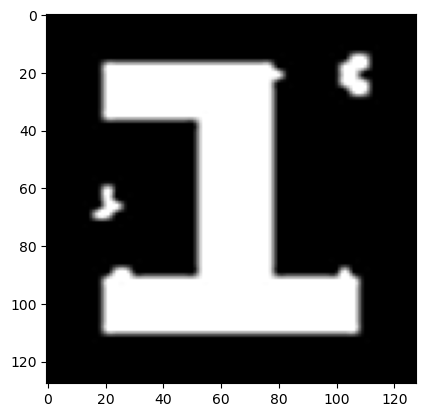

Predicted label for test image: n


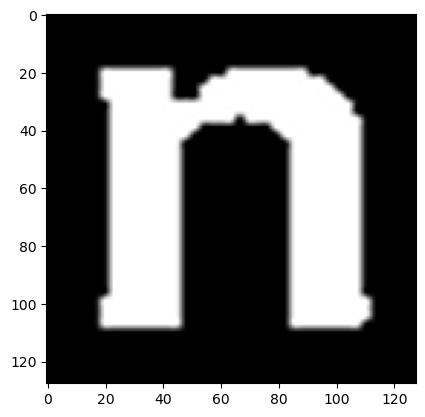

Predicted label for test image: e


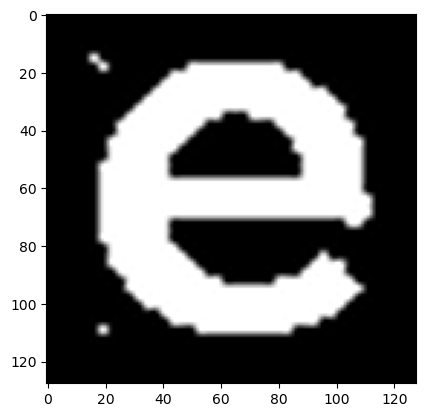

Predicted label for test image: M


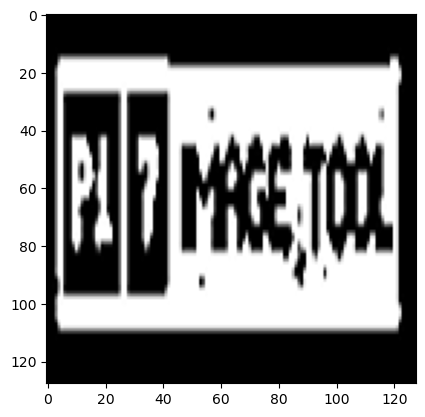

Predicted label for test image: Q


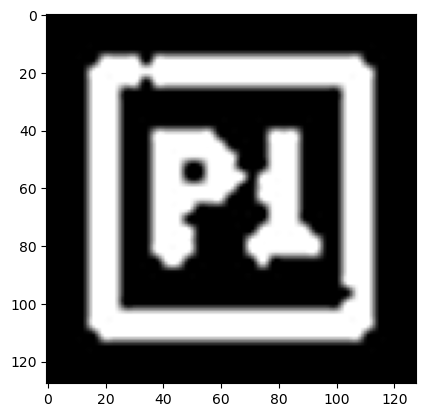

Predicted label for test image: E


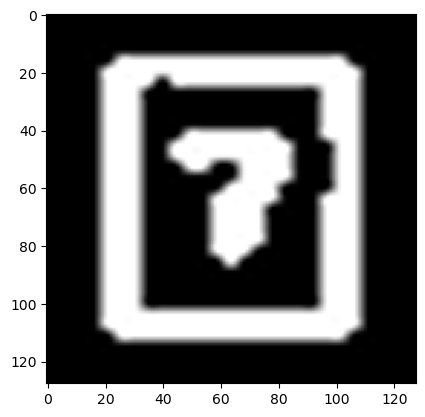

Predicted label for test image: H


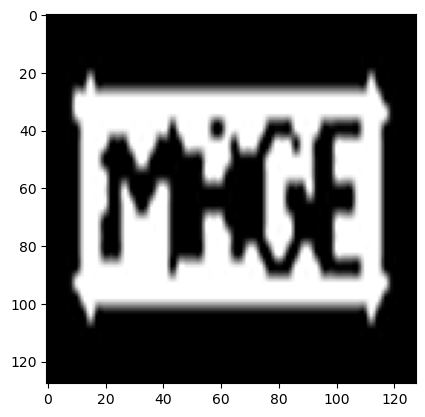

In [264]:
unique_boxes = sort_boxes_reading_order(unique_boxes, y_thresh=10)
words = merge_char_words(unique_boxes, x_thresh=20, y_thresh=30)
print(f"Number of words: {len(words)}")
text = ""
for word in words:
    for box in word:
        x, y, w, h = box
        # print(f"width: {w}, height: {h}")
        # print(f"Box {i}: x={x}, y={y}")
        char_img = gray[y:y+h, x:x+w]
        char_img = cv2.copyMakeBorder(char_img, 5, 5, 5, 5, cv2.BORDER_CONSTANT, value=255)

        char_img = cv2.GaussianBlur(char_img, (5, 5), 0)
        # binary_char_img = cv2.adaptiveThreshold(char_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

        char_img = cv2.adaptiveThreshold(
            char_img,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            11,
            2
        )

        char_img_resized = cv2.resize(
            char_img,
            (128, 128),
            interpolation=cv2.INTER_CUBIC
        )

        char_img_resized = char_img_resized.astype(np.float32) / 255.0

        magnitudes, orientations = calc_gradients(char_img_resized)
        features = HoG(orientations, magnitudes)
        predicted_label, scores = predict(char_img_resized)
        print("Predicted label for test image:", label_encoder.inverse_transform(predicted_label)[0])
        plt.imshow(char_img_resized, cmap='gray')
        plt.show()
        text += label_encoder.inverse_transform(predicted_label)[0]
    text += " "

In [265]:
toLower = text.lower()
print(toLower)

m r s u eduhu aext hao gme5xh hmague annn1ne m qeh 
